# Task 3: Energy Consumption Time Series Forecasting

In [1]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Task 3\household_power_consumption.csv")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [3]:
# Explore Dataset
df.shape

(1048575, 9)

In [4]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [6]:
df.describe()

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [7]:
df.isnull().sum()

Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           4069
dtype: int64

In [8]:
#Parse Date and Time
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0,2006-12-16 17:28:00


In [9]:
# Set Datetime as Index
df.set_index("Datetime", inplace=True)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [10]:
# Convert Columns to Numeric
numeric_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
# Handle Missing Values
df.isnull().sum()

Date                        0
Time                        0
Global_active_power      4069
Global_reactive_power    4069
Voltage                  4069
Global_intensity         4069
Sub_metering_1           4069
Sub_metering_2           4069
Sub_metering_3           4069
dtype: int64

In [12]:
df = df.fillna(method="ffill")

df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [13]:
# Drop Unnecessary Columns
df.drop(["Date", "Time"], axis=1, inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [14]:
## Resample Time Series
df = df.resample("h").mean()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [15]:
# Feature Engineering
df["Hour"] = df.index.hour
df["Day"] = df.index.day
df["Month"] = df.index.month
df["Weekday"] = df.index.weekday
df["Weekend"] = (df["Weekday"] >= 5).astype(int)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,Weekday,Weekend
Datetime,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,16,12,5,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,16,12,5,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,16,12,5,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,16,12,5,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,16,12,5,1


In [16]:
# Select Features and Target
X = df[["Hour", "Day", "Month", "Weekday", "Weekend"]]

y = df["Global_active_power"]

In [17]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [18]:
# ARIMA Model
arima_model = ARIMA(y_train, order=(5,1,0))

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(y_test))

In [19]:
# Evaluate ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

arima_mae = mean_absolute_error(y_test, arima_pred)

arima_rmse = root_mean_squared_error(y_test, arima_pred)

print("ARIMA MAE :", arima_mae)
print("ARIMA RMSE :", arima_rmse)

ARIMA MAE : 0.712614473032731
ARIMA RMSE : 1.1193486883112187


In [20]:
# Prepare Data for Prophet
prophet_df = df.reset_index()[["Datetime", "Global_active_power"]]

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2006-12-16 17:00:00,4.222889
1,2006-12-16 18:00:00,3.632200
2,2006-12-16 19:00:00,3.400233
3,2006-12-16 20:00:00,3.268567
4,2006-12-16 21:00:00,3.056467


In [23]:
from prophet import Prophet

In [24]:
# Train Prophet Model
prophet_model = Prophet()

prophet_model.fit(prophet_df)

01:16:42 - cmdstanpy - INFO - Chain [1] start processing
01:16:47 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
# Forecast using Prophet
future = prophet_model.make_future_dataframe(periods=24, freq="h")

forecast = prophet_model.predict(future)

forecast[["ds", "yhat"]].tail()

,ds,yhat
17496,2008-12-14 17:00:00,1.523979
17497,2008-12-14 18:00:00,1.879577
17498,2008-12-14 19:00:00,2.303380
17499,2008-12-14 20:00:00,2.513678
17500,2008-12-14 21:00:00,2.355726


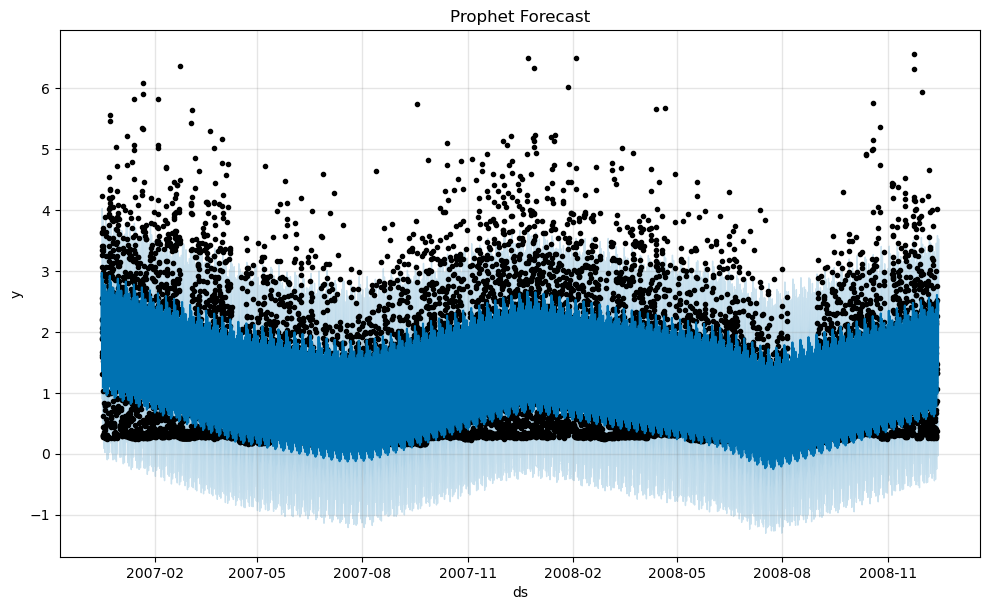

In [26]:
# Prophet Forecast Plot
prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

In [28]:
from xgboost import XGBRegressor

In [29]:
# XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [30]:
# Evaluate XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE :", xgb_rmse)

XGBoost MAE : 0.5204177827118441
XGBoost RMSE : 0.7010671386602817


In [31]:
# Evaluate Prophet
forecast_test = forecast.iloc[:len(prophet_df)]

In [32]:
# Evaluate Prophet
prophet_actual = prophet_df["y"]

prophet_pred = forecast["yhat"][:len(prophet_actual)]

prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)

prophet_rmse = root_mean_squared_error(prophet_actual, prophet_pred)

print("Prophet MAE :", prophet_mae)
print("Prophet RMSE :", prophet_rmse)

Prophet MAE : 0.5947723138730271
Prophet RMSE : 0.7931012613110315


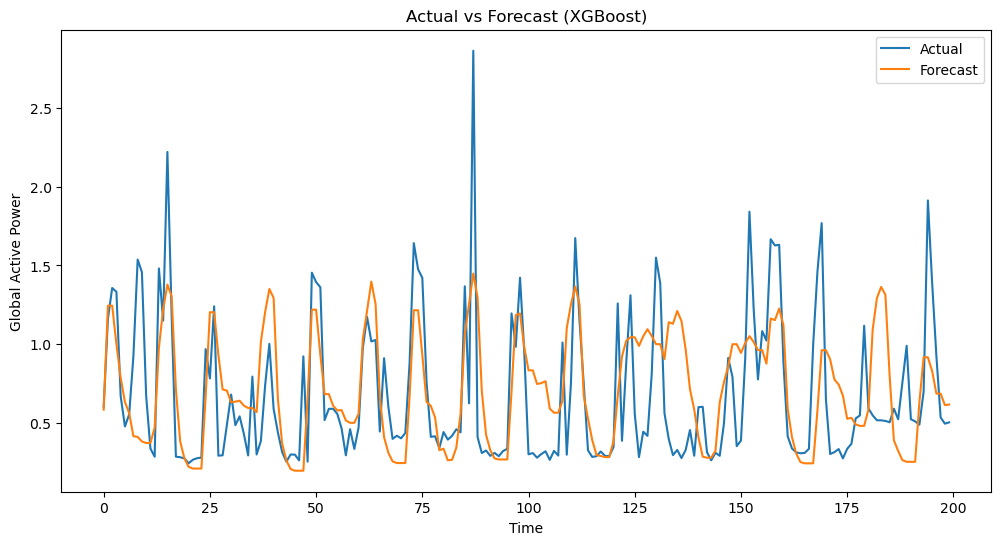

In [33]:
# Actual vs Forecast (XGBoost)
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")

plt.plot(xgb_pred[:200], label="Forecast")

plt.title("Actual vs Forecast (XGBoost)")
plt.xlabel("Time")
plt.ylabel("Global Active Power")

plt.legend()

plt.show()

In [34]:
# Model Comparison
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "MAE": [arima_mae, prophet_mae, xgb_mae],
    "RMSE": [arima_rmse, prophet_rmse, xgb_rmse]
})

comparison

,Model,MAE,RMSE
0,ARIMA,0.712614,1.119349
1,Prophet,0.594772,0.793101
2,XGBoost,0.520418,0.701067


Conclusion

This project successfully applied time series forecasting techniques to predict short-term household energy consumption. The dataset was parsed and resampled into hourly data, and time-based features such as hour, day, month, weekday, and weekend were engineered. Three forecasting models, ARIMA, Prophet, and XGBoost, were compared using MAE and RMSE. Among the models, XGBoost achieved the best performance with the lowest error values, indicating its ability to capture non-linear patterns in energy consumption data. The actual vs forecast plot also showed that XGBoost predictions closely followed the actual energy usage trend. Therefore, XGBoost was identified as the most effective model for this forecasting task.